Using device: cuda
GPU: Tesla T4
Train path: /kaggle/input/datasets/abidarahman1997/dataset1/Dataset1/train/images
Test path: /kaggle/input/datasets/abidarahman1997/dataset1/Dataset1/test/images
Train images: 2533
Test images: 318
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 193MB/s]  


Model: Mask R-CNN ResNet50-FPN
Model parameters: 43949305
Epoch 1/30 completed | Average loss: 0.4125 | Time: 605.24 sec
Epoch 2/30 completed | Average loss: 0.2567 | Time: 456.43 sec
Epoch 3/30 completed | Average loss: 0.2154 | Time: 450.27 sec
Epoch 4/30 completed | Average loss: 0.1960 | Time: 450.64 sec
Epoch 5/30 completed | Average loss: 0.1788 | Time: 443.91 sec
Epoch 6/30 completed | Average loss: 0.1650 | Time: 443.78 sec
Epoch 7/30 completed | Average loss: 0.1541 | Time: 446.14 sec
Epoch 8/30 completed | Average loss: 0.1504 | Time: 444.21 sec
Epoch 9/30 completed | Average loss: 0.1398 | Time: 436.04 sec
Epoch 10/30 completed | Average loss: 0.1313 | Time: 438.31 sec
Epoch 11/30 completed | Average loss: 0.1407 | Time: 439.11 sec
Epoch 12/30 completed | Average loss: 0.1424 | Time: 443.59 sec
Epoch 13/30 completed | Average loss: 0.1207 | Time: 449.61 sec
Epoch 14/30 completed | Average loss: 0.1182 | Time: 440.04 sec
Epoch 15/30 completed | Average loss: 0.1197 | Time: 44

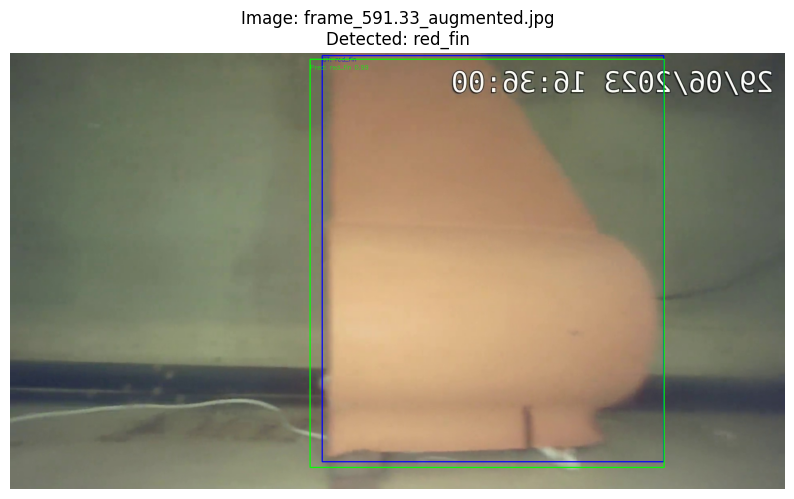

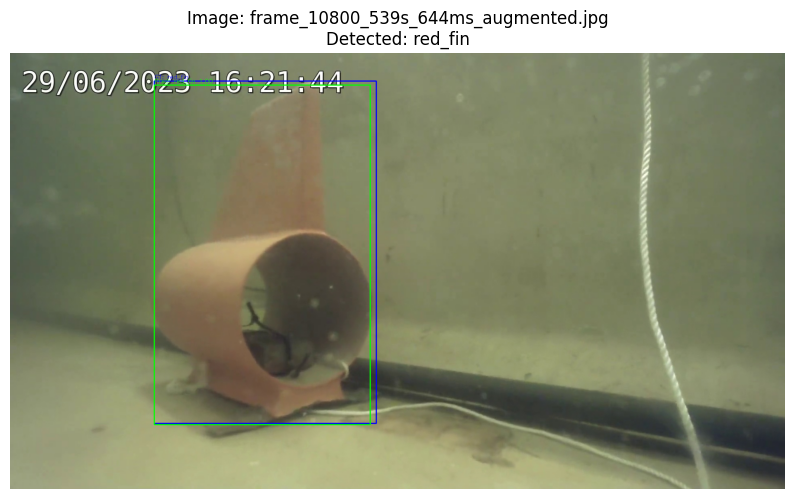

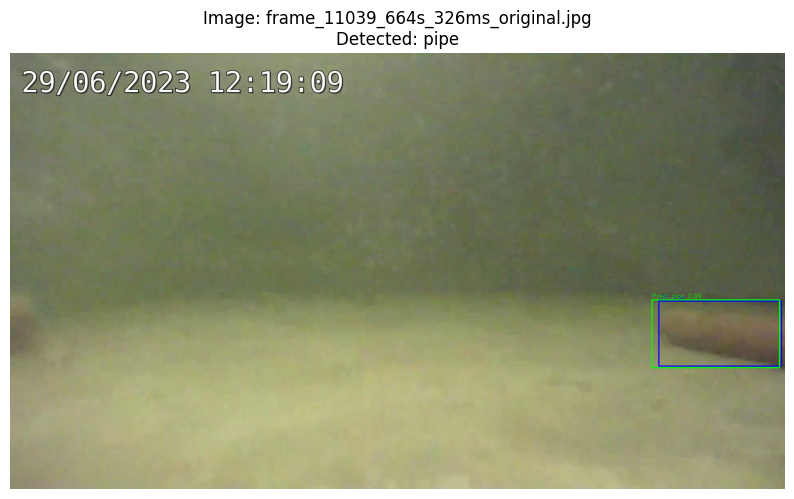

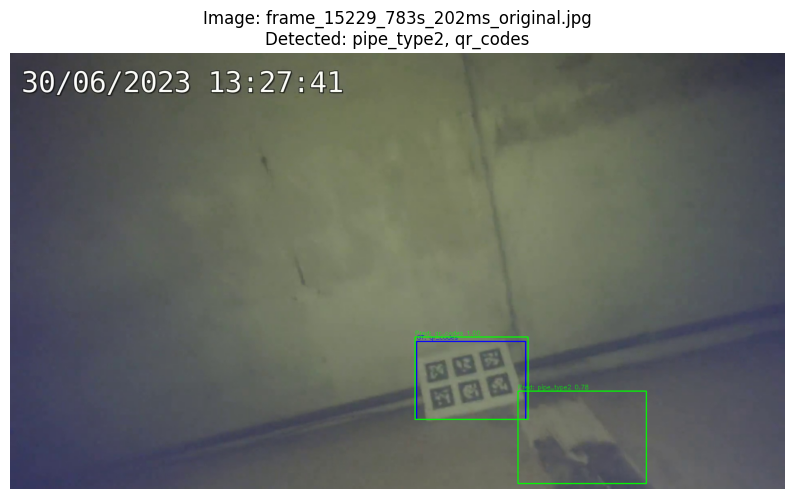

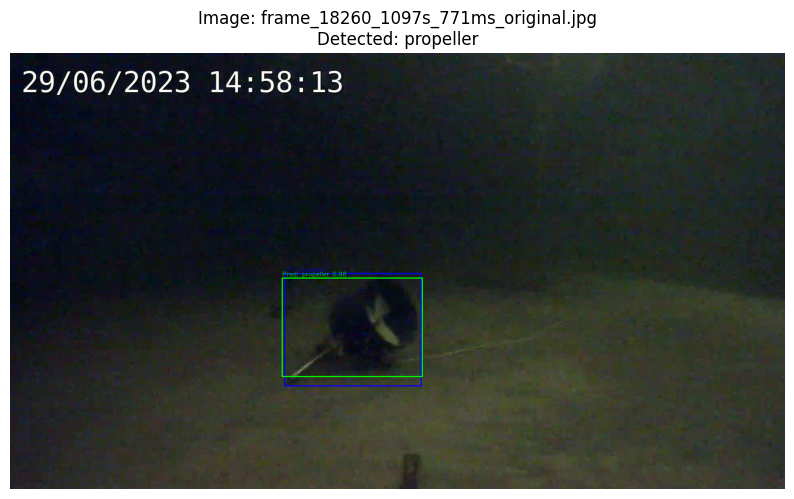


Final summary:
{
  "model": "Mask R-CNN ResNet50-FPN",
  "parameters": 43949305,
  "training_time_seconds": 13469.756691455841,
  "avg_inference_time_seconds": 0.1676050656996433,
  "total_test_inference_time_seconds": 26.649205446243286,
  "fps": 11.932813555791329,
  "map50_percent": 95.27474975585938,
  "map50_95_percent": 74.31996154785156,
  "precision_percent": 80.90551181102363,
  "recall_percent": 94.48275862068965,
  "detection_accuracy_percent": 80.90551181102363,
  "batch_size_train": 2,
  "batch_size_test": 2,
  "num_epochs": 30
}


In [4]:
!pip install -q torchmetrics opencv-python pillow matplotlib

import os, cv2, glob, json, time, random, gc, warnings
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

warnings.filterwarnings("ignore")

# =========================
# Speed settings
# =========================
torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

if torch.cuda.is_available():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# Paths
# =========================
DATASET_PATH = "/kaggle/input/datasets/abidarahman1997/dataset1/Dataset1"

TRAIN_IMG = f"{DATASET_PATH}/train/images"
TRAIN_LBL = f"{DATASET_PATH}/train/labels"

TEST_IMG = f"{DATASET_PATH}/test/images"
TEST_LBL = f"{DATASET_PATH}/test/labels"

RESULTS_DIR = "/kaggle/working/mask_rcnn_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# =========================
# Config
# =========================
CLASSES = ["propeller", "pipe_type2", "red_fin", "net", "qr_codes", "pipe"]

# Mask R-CNN uses background class, so +1 is required
NUM_CLASSES = len(CLASSES) + 1

CONF_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5
VIS_SAMPLES = 5

BATCH_SIZE_TRAIN = 2
BATCH_SIZE_TEST = 2

NUM_EPOCHS = 30
NUM_WORKERS = 2

# For quick test, use:
# NUM_EPOCHS = 1

# =========================
# Helper functions
# =========================
def list_images(folder):
    return sorted(
        glob.glob(os.path.join(folder, "*.jpg")) +
        glob.glob(os.path.join(folder, "*.jpeg")) +
        glob.glob(os.path.join(folder, "*.png"))
    )

def read_yolo_labels(txt_file, W, H, class_shift=0):
    boxes, labels = [], []

    if not os.path.exists(txt_file):
        return boxes, labels

    with open(txt_file, "r") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            c, x, y, w, h = parts
            c = int(float(c)) + class_shift
            x, y, w, h = map(float, [x, y, w, h])

            x1 = (x - w / 2) * W
            y1 = (y - h / 2) * H
            x2 = (x + w / 2) * W
            y2 = (y + h / 2) * H

            x1 = max(0, min(x1, W - 1))
            y1 = max(0, min(y1, H - 1))
            x2 = max(0, min(x2, W - 1))
            y2 = max(0, min(y2, H - 1))

            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(c)

    return boxes, labels

def boxes_to_masks(boxes, H, W):
    masks = []

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        mask = np.zeros((H, W), dtype=np.uint8)
        mask[y1:y2, x1:x2] = 1

        masks.append(mask)

    if len(masks) == 0:
        return torch.zeros((0, H, W), dtype=torch.uint8)

    return torch.as_tensor(np.stack(masks), dtype=torch.uint8)

def iou_xyxy(a, b):
    xA = max(a[0], b[0])
    yA = max(a[1], b[1])
    xB = min(a[2], b[2])
    yB = min(a[3], b[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    areaA = max(0, a[2] - a[0]) * max(0, a[3] - a[1])
    areaB = max(0, b[2] - b[0]) * max(0, b[3] - b[1])

    union = areaA + areaB - inter

    return inter / union if union > 0 else 0.0

def collate_fn(batch):
    return tuple(zip(*batch))

# =========================
# Dataset
# =========================
class YOLOMaskRCNNDataset(Dataset):
    def __init__(self, images_dir, labels_dir):
        self.images = list_images(images_dir)
        self.labels_dir = labels_dir

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]

        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        label_path = os.path.join(
            self.labels_dir,
            os.path.splitext(os.path.basename(img_path))[0] + ".txt"
        )

        # Mask R-CNN needs labels 1 to 6. Label 0 is background.
        boxes, labels = read_yolo_labels(label_path, W, H, class_shift=1)

        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            masks_t = torch.zeros((0, H, W), dtype=torch.uint8)
            area_t = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)
            masks_t = boxes_to_masks(boxes, H, W)

            area_t = (boxes_t[:, 2] - boxes_t[:, 0]) * (boxes_t[:, 3] - boxes_t[:, 1])

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "masks": masks_t,
            "image_id": torch.tensor([idx], dtype=torch.int64),
            "area": area_t,
            "iscrowd": torch.zeros((len(labels_t),), dtype=torch.int64)
        }

        return F.to_tensor(img), target

# =========================
# DataLoaders
# =========================
train_dataset = YOLOMaskRCNNDataset(TRAIN_IMG, TRAIN_LBL)
test_dataset = YOLOMaskRCNNDataset(TEST_IMG, TEST_LBL)

print("Train path:", TRAIN_IMG)
print("Test path:", TEST_IMG)
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

if len(train_dataset) == 0:
    raise ValueError(f"No training images found in: {TRAIN_IMG}")

if len(test_dataset) == 0:
    raise ValueError(f"No test images found in: {TEST_IMG}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_TRAIN,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_TEST,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

# =========================
# Model: Mask R-CNN
# =========================
MODEL_NAME = "Mask R-CNN ResNet50-FPN"

model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

# Replace box classifier
in_features_box = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features_box,
    NUM_CLASSES
)

# Replace mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256

model.roi_heads.mask_predictor = MaskRCNNPredictor(
    in_features_mask,
    hidden_layer,
    NUM_CLASSES
)

model.to(DEVICE)

param_count = sum(p.numel() for p in model.parameters())

print("Model:", MODEL_NAME)
print("Model parameters:", param_count)

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

# =========================
# Training
# Prints only after every epoch
# =========================
train_start = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()

    for images, targets in train_loader:
        images = [
            img.to(DEVICE, non_blocking=True)
            for img in images
        ]

        targets = [
            {
                k: v.to(DEVICE, non_blocking=True)
                for k, v in t.items()
            }
            for t in targets
        ]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += losses.item()

    epoch_time = time.time() - epoch_start
    avg_epoch_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} completed | "
        f"Average loss: {avg_epoch_loss:.4f} | "
        f"Time: {epoch_time:.2f} sec"
    )

train_end = time.time()
training_seconds = train_end - train_start

print(f"\nTotal training time: {training_seconds:.2f} seconds")

# =========================
# Evaluation - box metrics only
# =========================
metric = MeanAveragePrecision(iou_type="bbox")
model.eval()

TP = 0
FP = 0
FN = 0
correct = 0
total_preds = 0
times = []

with torch.no_grad():
    for images, targets in test_loader:
        images = [
            img.to(DEVICE, non_blocking=True)
            for img in images
        ]

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start = time.time()

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            outputs = model(images)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        end = time.time()
        times.append(end - start)

        preds_map, gts_map = [], []

        for output, target in zip(outputs, targets):
            output_boxes = output["boxes"].detach().cpu()
            output_scores = output["scores"].detach().cpu()
            output_labels = output["labels"].detach().cpu()

            target_boxes = target["boxes"].detach().cpu()
            target_labels = target["labels"].detach().cpu()

            preds_map.append({
                "boxes": output_boxes,
                "scores": output_scores,
                "labels": output_labels
            })

            gts_map.append({
                "boxes": target_boxes,
                "labels": target_labels
            })

            pred_boxes = output_boxes.numpy().tolist()
            pred_scores = output_scores.numpy().tolist()
            pred_labels = output_labels.numpy().tolist()

            gt_boxes = target_boxes.numpy().tolist()
            gt_labels = target_labels.numpy().tolist()

            keep = [
                i for i, s in enumerate(pred_scores)
                if s >= CONF_THRESHOLD
            ]

            pred_boxes = [pred_boxes[i] for i in keep]
            pred_labels = [pred_labels[i] for i in keep]

            matched_gt = set()

            for pb, pl in zip(pred_boxes, pred_labels):
                total_preds += 1

                best_iou = 0.0
                best_idx = -1

                for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                    if j in matched_gt or pl != gl:
                        continue

                    current_iou = iou_xyxy(pb, gb)

                    if current_iou > best_iou:
                        best_iou = current_iou
                        best_idx = j

                if best_iou >= IOU_THRESHOLD and best_idx != -1:
                    TP += 1
                    correct += 1
                    matched_gt.add(best_idx)
                else:
                    FP += 1

            FN += len(gt_boxes) - len(matched_gt)

        metric.update(preds_map, gts_map)

results = metric.compute()

precision = (TP / (TP + FP) * 100) if (TP + FP) > 0 else 0.0
recall = (TP / (TP + FN) * 100) if (TP + FN) > 0 else 0.0
detection_accuracy = (correct / total_preds * 100) if total_preds > 0 else 0.0

avg_inference_time = float(np.mean(times)) if times else 0.0
total_inference_time = float(np.sum(times)) if times else 0.0
fps = (len(test_dataset) / total_inference_time) if total_inference_time > 0 else 0.0

# =========================
# Visualization
# =========================
sample_imgs = os.listdir(TEST_IMG)[:VIS_SAMPLES]

for img_name in sample_imgs:
    img_path = os.path.join(TEST_IMG, img_name)

    img = cv2.imread(img_path)

    if img is None:
        continue

    H, W, _ = img.shape
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lbl_path = os.path.join(
        TEST_LBL,
        os.path.splitext(img_name)[0] + ".txt"
    )

    gt_boxes, gt_labels = read_yolo_labels(lbl_path, W, H, class_shift=1)

    detected_names = []

    for b, lbl in zip(gt_boxes, gt_labels):
        x1, y1, x2, y2 = map(int, b)

        if 1 <= lbl <= len(CLASSES):
            class_name = CLASSES[lbl - 1]
        else:
            class_name = "unknown"

        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(
            img_rgb,
            f"GT: {class_name}",
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 0, 255),
            1
        )

    with torch.no_grad():
        input_tensor = F.to_tensor(img_rgb).to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            pred = model([input_tensor])[0]

    pred_boxes = pred["boxes"].detach().cpu().numpy()
    pred_scores = pred["scores"].detach().cpu().numpy()
    pred_labels = pred["labels"].detach().cpu().numpy()

    for b, s, lbl in zip(pred_boxes, pred_scores, pred_labels):
        if s < CONF_THRESHOLD:
            continue

        if not (1 <= lbl <= len(CLASSES)):
            continue

        x1, y1, x2, y2 = map(int, b)

        class_name = CLASSES[lbl - 1]
        detected_names.append(class_name)

        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img_rgb,
            f"Pred: {class_name} {s:.2f}",
            (x1, max(40, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(
        f"Image: {img_name}\n"
        f"Detected: {', '.join(sorted(set(detected_names))) if detected_names else 'No object detected'}"
    )
    plt.axis("off")
    plt.show()

# =========================
# Save summary
# =========================
summary = {
    "model": MODEL_NAME,
    "parameters": int(param_count),
    "training_time_seconds": float(training_seconds),
    "avg_inference_time_seconds": avg_inference_time,
    "total_test_inference_time_seconds": total_inference_time,
    "fps": fps,
    "map50_percent": float(results["map_50"] * 100),
    "map50_95_percent": float(results["map"] * 100),
    "precision_percent": float(precision),
    "recall_percent": float(recall),
    "detection_accuracy_percent": float(detection_accuracy),
    "batch_size_train": BATCH_SIZE_TRAIN,
    "batch_size_test": BATCH_SIZE_TEST,
    "num_epochs": NUM_EPOCHS
}

with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nFinal summary:")
print(json.dumps(summary, indent=2))